# Thai Medical QA / RAG — Dataset + Data Engineering Starter (Notebook)

This notebook uses **Thaweewat/thai-med-pack** from Hugging Face and helps you:

- Load + inspect the dataset (Thai medical Q&A style)
- Parse instruction-style text into structured fields: `question`, `answer`
- Do basic data engineering (cleaning, dedupe, privacy/PII-risk scan, safety filtering, split)
- Build a retrieval corpus by chunking answers/contexts
- Export `jsonl` files for model training / RAG indexing

> ⚠️ Note: Some entries may include **sensitive topics** (e.g., sexual health, minors, mental health crises).  
> For an academic MVP, you should **filter** sensitive content and keep the system as **decision-support only**.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# If needed, install deps (uncomment)
# !pip install -U datasets pandas

import re, json, os, random, hashlib
import pandas as pd
from datasets import load_dataset
import tqdm as notebook_tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)


## 1) Load dataset: Thaweewat/thai-med-pack

This dataset is provided as an instruction-style text field (typically one column: `text`).
We'll load the `train` split and parse the `[INST] ... [/INST]` part into question & answer.


In [3]:
ds = load_dataset("Thaweewat/thai-med-pack")
# Typically only 'train' split is provided
df_raw = ds[list(ds.keys())[0]].to_pandas()
df_raw.head()


README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

thai_med_pack.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/189190 [00:00<?, ? examples/s]

,text
0,<s>[INST] สวัสดีค่ะ อยากรู้ว่าต้องทำยังไงคะมีอ...
1,<s>[INST] อยากทราบว่ากินยาคลุมฉุกเฉินชนิด 1 เม...
2,<s>[INST] ไม่รู้ว่าใช่ประจำเดือนหรือป่าว แต่เล...
3,<s>[INST] ตอนนี้หนูอายุ13ปีและหนูเป็นนางรำของร...
4,<s>[INST] ตามต้นหัวข้อเลยค่ะ เราเป็นคนที่คิดมา...


## 2) Parse instruction format into structured QA

Expected pattern in `text` (example):
- `<s>[INST] ...question... [/INST] ...answer... </s>`

We will extract:
- `question`
- `answer`

If an entry does not match the pattern, it will be dropped (or kept in `unparsed` for audit).


In [4]:
WS_RE = re.compile(r"\s+")
INST_RE = re.compile(r"\[INST\](.*?)\[/INST\](.*)", re.DOTALL)

def sha1(text: str) -> str:
    return hashlib.sha1(text.encode("utf-8", errors="ignore")).hexdigest()

def clean_text(s) -> str:
    if s is None:
        return ""
    s = str(s).replace("\u00a0", " ")
    s = WS_RE.sub(" ", s).strip()
    return s

def parse_inst(sample: str):
    if not sample:
        return None, None
    m = INST_RE.search(sample)
    if not m:
        return None, None
    q = clean_text(m.group(1))
    a = clean_text(m.group(2))
    # strip common special tokens
    q = q.replace("<s>", "").replace("</s>", "").strip()
    a = a.replace("<s>", "").replace("</s>", "").strip()
    return q, a

# Parse
text_col = "text"
if text_col not in df_raw.columns:
    # Sometimes datasets use 'prompt' or similar; fallback: first column
    text_col = df_raw.columns[0]

parsed = df_raw[text_col].map(parse_inst)
df = pd.DataFrame(parsed.tolist(), columns=["question", "answer"])

# Keep raw for auditing if needed
df["raw_text"] = df_raw[text_col].astype(str).map(lambda x: x[:5000])  # cap length

# Drop unparsed
unparsed = df[df["question"].isna() | df["answer"].isna()].copy()
df = df.dropna(subset=["question", "answer"]).reset_index(drop=True)

# Make stable id
df["id"] = [sha1(f"{q}||{a}||{i}") for i, (q, a) in enumerate(zip(df["question"], df["answer"]))]

df = df[["id", "question", "answer", "raw_text"]]
df.head(), len(df), len(unparsed)


(                                         id  \
 0  cc79cd4e61194d7f30c078bd9f54aa0c94c43f64   
 1  f21051455d5c19c9b7b52096b4fafc3abc7bc88c   
 2  ca64cdd9d62e666f9c72debdbc24945302529c5a   
 3  1e348c10ee823d318858e51c7fddea63a0344ac2   
 4  bd311f898481fe58d118026962b1be27795adbc3   
 
                                             question  \
 0  สวัสดีค่ะ อยากรู้ว่าต้องทำยังไงคะมีอาการคันอวั...   
 1  อยากทราบว่ากินยาคลุมฉุกเฉินชนิด 1 เม็ด แล้วประ...   
 2  ไม่รู้ว่าใช่ประจำเดือนหรือป่าว แต่เลือกมันเป็น...   
 3  ตอนนี้หนูอายุ13ปีและหนูเป็นนางรำของร.ร.แต่หนูร...   
 4  ตามต้นหัวข้อเลยค่ะ เราเป็นคนที่คิดมากอยู่แล้ว ...   
 
                                               answer  \
 0  สวัสดีค่ะ อาการคันอวัยวะเพศหญิง อาจเกิดจาก-รูข...   
 1  สวัสดีค่ะ หลังใข้ยาคุมฉุกเฉินอาจทำให้มีเลือดออ...   
 2  สวัสดีค่ะ หากเลือดที่ออก อยู่ในช่วงวันที่ประจำ...   
 3  สวัสดีค่ะ ฟังจากเหตุการณ์และความคิดของ น่าจะมี...   
 4  สวัสดีค่ะ อาการร้องไห้ง่ายขึ้น มีพฤติกรรมทำร้า...   
 
                      

## 3) Privacy / PDPA + Safety filtering (recommended)

Even if this is a public dataset, the content may include:
- **minors** (age stated)
- sensitive sexual health topics
- mental health crises / self-harm mentions

We will:
1) Do a **conservative PII-risk scan** (email/phone/Thai ID format)  
2) Optionally filter **high-risk sensitive content** using keyword heuristics (editable list)

> This is NOT perfect. Treat it as an engineering safeguard + audit trail.


In [5]:
EMAIL_RE = re.compile(r"\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b", re.I)
PHONE_RE = re.compile(r"\b(?:\+?\d{1,3}[- ]?)?(?:\(?\d{2,3}\)?[- ]?)?\d{3}[- ]?\d{4}\b")
THAI_ID_RE = re.compile(r"\b\d{1}-\d{4}-\d{5}-\d{2}-\d\b")

# Sensitive-topic heuristics (tune for your project)
SENSITIVE_PATTERNS = [
    r"ฆ่าตัวตาย", r"ทำร้ายตัวเอง", r"กรีด", r"ผูกคอ", r"อยากตาย",
    r"ข่มขืน", r"ล่วงละเมิด",
]
SENSITIVE_RE = re.compile("|".join(SENSITIVE_PATTERNS))

def pii_risk_flag(text: str) -> bool:
    if not text:
        return False
    if EMAIL_RE.search(text): return True
    if THAI_ID_RE.search(text): return True
    if PHONE_RE.search(text): return True
    return False

def sensitive_flag(text: str) -> bool:
    if not text:
        return False
    return bool(SENSITIVE_RE.search(text))

flags_pii = df.apply(lambda r: pii_risk_flag(r["question"]) or pii_risk_flag(r["answer"]), axis=1)
flags_sensitive = df.apply(lambda r: sensitive_flag(r["question"]) or sensitive_flag(r["answer"]), axis=1)

df_pii_flagged = df[flags_pii].copy()
df_sensitive_flagged = df[flags_sensitive].copy()

df_kept = df[~(flags_pii | flags_sensitive)].copy().reset_index(drop=True)

len(df), len(df_kept), len(df_pii_flagged), len(df_sensitive_flagged)


(189190, 186172, 358, 2667)

## 4) Dedupe + clean

- Dedupe by `(question, answer)`
- Drop empty rows


In [6]:
def dedupe(df_in: pd.DataFrame) -> pd.DataFrame:
    tmp = df_in.copy()
    tmp["_key"] = (tmp["question"].fillna("") + "||" + tmp["answer"].fillna("")).map(sha1)
    tmp = tmp.drop_duplicates(subset=["_key"]).drop(columns=["_key"]).reset_index(drop=True)
    return tmp

df_clean = dedupe(df_kept)
df_clean = df_clean[(df_clean["question"].str.len() > 0) & (df_clean["answer"].str.len() > 0)].reset_index(drop=True)

df_clean.shape


(186059, 4)

## 5) Split Train/Val/Test

This dataset may not have labels, so we do a random split by default.


In [7]:
def random_split(df_in: pd.DataFrame, train=0.8, val=0.1, test=0.1, seed=RANDOM_SEED):
    assert abs(train + val + test - 1.0) < 1e-9
    idx = list(df_in.index)
    rng = random.Random(seed)
    rng.shuffle(idx)
    n = len(idx)
    n_train = int(n * train)
    n_val = int(n * val)
    train_df = df_in.loc[idx[:n_train]].reset_index(drop=True)
    val_df = df_in.loc[idx[n_train:n_train+n_val]].reset_index(drop=True)
    test_df = df_in.loc[idx[n_train+n_val:]].reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = random_split(df_clean, 0.8, 0.1, 0.1)

len(train_df), len(val_df), len(test_df)


(148847, 18605, 18607)

## 6) Build retrieval corpus (chunk answers)

For a simple RAG baseline, we can index the **answers** (or combine question+answer).
If you later add external guideline PDFs, replace this with guideline chunking.


In [8]:
def chunk_text(text: str, max_chars: int = 900, overlap: int = 120):
    text = clean_text(text)
    if not text:
        return []
    # sentence-ish split (Thai doesn't use periods consistently; still helps a bit)
    sents = re.split(r"(?<=[.!?。！？])\s+", text)
    chunks, cur = [], ""
    for s in sents:
        if not s:
            continue
        if len(cur) + 1 + len(s) <= max_chars:
            cur = (cur + " " + s).strip()
        else:
            if cur:
                chunks.append(cur)
            cur = s
    if cur:
        chunks.append(cur)

    final = []
    for ch in chunks:
        if len(ch) <= max_chars:
            final.append(ch)
        else:
            start = 0
            while start < len(ch):
                final.append(ch[start:start + max_chars])
                start += max(1, max_chars - overlap)
    return final

def build_corpus(df_in: pd.DataFrame, max_chars=900):
    rows = []
    for _, r in df_in.iterrows():
        doc_id = r["id"]
        # Index answer alone, or (Q+A) if you prefer:
        base = f"Q: {r['question']}\nA: {r['answer']}"
        for j, ch in enumerate(chunk_text(base, max_chars=max_chars, overlap=max(20, int(max_chars*0.15)))):
            rows.append({"doc_id": doc_id, "chunk_id": f"{doc_id}-{j:03d}", "text": ch})
    return pd.DataFrame(rows)

corpus_df = build_corpus(train_df, max_chars=900)
corpus_df.head(), len(corpus_df)


(                                     doc_id  \
 0  cf4f80246e8f4aa4527acde329e708728ef2fb85   
 1  8a119092792fd342caa44cd757208b9b60b0cef2   
 2  8a119092792fd342caa44cd757208b9b60b0cef2   
 3  bf96be8699b1126bff81647bbe4bc236ae49e269   
 4  bf96be8699b1126bff81647bbe4bc236ae49e269   
 
                                        chunk_id  \
 0  cf4f80246e8f4aa4527acde329e708728ef2fb85-000   
 1  8a119092792fd342caa44cd757208b9b60b0cef2-000   
 2  8a119092792fd342caa44cd757208b9b60b0cef2-001   
 3  bf96be8699b1126bff81647bbe4bc236ae49e269-000   
 4  bf96be8699b1126bff81647bbe4bc236ae49e269-001   
 
                                                 text  
 0  Q: ผมโดนเเมวข่วนแมวยังไม่ฉีดยาพึ่งอายุ2เดือนกว...  
 1  Q: เป็นเวลาหนึ่งสัปดาห์แล้วที่ฉันรู้สึกแสบท้อง...  
 2  ราโซล 20 มก., แพนโทพราโซล 40 มก., โอเมพราโซล 2...  
 3  Q: คืิผมอานุแค่14ครับมีตุ่ทที่โคนลิ้นเจ็บไม่เจ...  
 4  เป็นอาการแสดงของโรคติดเชื้อต่างๆ เช่น โรคมือเท...  ,
 225332)

## 7) Export JSONL (+ audit files)

Outputs:
- `qa_train.jsonl`, `qa_val.jsonl`, `qa_test.jsonl`
- `corpus.jsonl`
- `pii_flagged.jsonl` (audit)
- `sensitive_flagged.jsonl` (audit)


In [9]:
def to_jsonl(df_in: pd.DataFrame, path: str):
    with open(path, "w", encoding="utf-8") as f:
        for row in df_in.to_dict(orient="records"):
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

outdir = "out_thai_med_pack"
os.makedirs(outdir, exist_ok=True)

to_jsonl(train_df.drop(columns=["raw_text"]), os.path.join(outdir, "qa_train.jsonl"))
to_jsonl(val_df.drop(columns=["raw_text"]),   os.path.join(outdir, "qa_val.jsonl"))
to_jsonl(test_df.drop(columns=["raw_text"]),  os.path.join(outdir, "qa_test.jsonl"))
to_jsonl(corpus_df, os.path.join(outdir, "corpus.jsonl"))

if len(df_pii_flagged) > 0:
    to_jsonl(df_pii_flagged, os.path.join(outdir, "pii_flagged.jsonl"))
if len(df_sensitive_flagged) > 0:
    to_jsonl(df_sensitive_flagged, os.path.join(outdir, "sensitive_flagged.jsonl"))

stats = {
    "rows_total_parsed": int(len(df)),
    "rows_unparsed": int(len(unparsed)),
    "rows_after_filters": int(len(df_clean)),
    "train": int(len(train_df)),
    "val": int(len(val_df)),
    "test": int(len(test_df)),
    "corpus_chunks_train": int(len(corpus_df)),
    "pii_flagged": int(len(df_pii_flagged)),
    "sensitive_flagged": int(len(df_sensitive_flagged)),
}
with open(os.path.join(outdir, "stats.json"), "w", encoding="utf-8") as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

stats


{'rows_total_parsed': 189190,
 'rows_unparsed': 0,
 'rows_after_filters': 186059,
 'train': 148847,
 'val': 18605,
 'test': 18607,
 'corpus_chunks_train': 225332,
 'pii_flagged': 358,
 'sensitive_flagged': 2667}

# Feature Engineering

**Feature หลักที่ใช้ (Engineered / Learned)**

* **Combined Q&A Context (Engineered)**: การสร้าง String ชุดใหม่ที่รวมทั้งคำถามและคำตอบเข้าด้วยกัน (รูปแบบ `Q: {question} A: {answer}`) เพื่อให้แต่ละ Chunk มีความหมายที่สมบูรณ์ในตัวเองก่อนนำไปประมวลผล

* **Semantic Chunks (Engineered)**: การแบ่งข้อความเป็นส่วนย่อย (Chunking) ขนาด 900 ตัวอักษร โดยมีส่วนที่ Overlap กัน 120 ตัวอักษร เพื่อรักษาความต่อเนื่องของเนื้อหาทางการแพทย์และป้องกันการขาดหายของบริบทที่รอยต่อ

* **Multilingual MPNet Embeddings (Learned)**: การแปลงข้อความภาษาไทยให้เป็นเวกเตอร์ความหมายขนาด 768 มิติ โดยใช้โมเดล paraphrase-multilingual-mpnet-base-v2 เพื่อใช้ในกระบวนการ Semantic Search

* **Content-Based Stable ID (Engineered)**: การสร้าง ID เฉพาะตัวด้วยการทำ SHA1 Hash จากเนื้อหา Q&A เพื่อใช้ระบุตัวตนของข้อมูลและป้องกันความซ้ำซ้อนในฐานข้อมูลเวกเตอร์

**เหตุผลในการเลือก Feature**

* **Semantic Mapping**: เลือกใช้ paraphrase-multilingual-mpnet-base-v2 เนื่องจากเป็นโมเดลที่ถูกฝึกมาเพื่อเน้นเรื่องการเปรียบเทียบความหมายของประโยค และรองรับภาษาไทยได้ดี ทำให้สามารถดึงข้อมูลที่เกี่ยวข้องได้แม้ผู้ใช้จะใช้คำถามที่ไม่ตรงกับ Keyword ในฐานข้อมูล

* **Contextual Integrity**: การทำ Chunking พร้อม Overlap ช่วยให้ระบบ RAG สามารถเข้าถึงข้อมูลที่เป็นคำแนะนำทางการแพทย์ได้อย่างต่อเนื่องและลดความผิดพลาดในการสร้างคำตอบ

**Feature ที่ตั้งใจไม่ใช้ (ถ้ามี)**

* **Raw Instruction Tokens**: เช่น `<s>`, `[INST]`, `[/INST]`, `</s> `จะถูกคัดออกเนื่องจากเป็นสัญลักษณ์ควบคุมทางเทคนิคที่ไม่ส่งผลต่อความหมายในเชิงการค้นหา

* **High-Risk Sensitive Mentions**: เนื้อหาที่เกี่ยวข้องกับภาวะวิกฤต เช่น การทำร้ายตัวเอง หรือการฆ่าตัวตาย ที่ถูก Flag ไว้ในขั้นตอนการทำความสะอาดข้อมูล จะไม่ถูกนำมาสร้างเป็น Feature เพื่อความปลอดภัยตามหลักจริยธรรมทางการแพทย์

* **PII (Personally Identifiable Information)**: ข้อมูลส่วนบุคคล เช่น หมายเลขโทรศัพท์ หรือเลขประจำตัวประชาชน จะถูกคัดออกเพื่อปฏิบัติตามหลักความเป็นส่วนตัวของข้อมูลสุขภาพ (PDPA)

Text Embedding using `paraphrase-multilingual-mpnet-base-v2`

In [10]:
# !pip install -U sentence-transformers
# from sentence_transformers import SentenceTransformer
# import torch
# import numpy as np

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# def generate_embeddings(df_corpus):
#     model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2', device=device)

#     sentences = df_corpus['text'].tolist()

#     embeddings = model.encode(
#         sentences,
#         show_progress_bar=True,
#         convert_to_numpy=True,
#         batch_size=32
#     )

#     return embeddings

# corpus_embeddings = generate_embeddings(corpus_df)
# np.save("out_thai_med_pack/corpus_embeddings.npy", corpus_embeddings)

# Model Section

In [11]:
!pip install -U accelerate sentence-transformers
!pip install -q -U faiss-cpu
!pip install openai google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.1 MB/s eta 0:00:00


## load embedding model

In [12]:
import torch
from sentence_transformers import SentenceTransformer
import numpy as np

# ── Embedding model — T4 GPU config ────────────────────────
# T4 has 16GB VRAM — can use the larger mpnet model at full speed
# batch_size=256 keeps GPU utilisation high without OOM

DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
EMBED_MODEL_NAME = "paraphrase-multilingual-mpnet-base-v2"   # back to full model
EMBED_BATCH_SIZE = 256   # T4: 256 safe; drop to 128 if OOM

embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
_ = embed_model.encode(["warmup"], batch_size=1, show_progress_bar=False)

print(f"✅ Embed model : {EMBED_MODEL_NAME}")
print(f"   Device      : {DEVICE}  ({torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'CPU fallback'})")
print(f"   Batch size  : {EMBED_BATCH_SIZE}")
print(f"   Dim         : {embed_model.get_sentence_embedding_dimension()}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embed model : paraphrase-multilingual-mpnet-base-v2
   Device      : cuda  (Tesla T4)
   Batch size  : 256
   Dim         : 768


## RAG Knowledge Ingestion

In [13]:
import faiss, os, json as _json, torch

DRIVE_DIR = "/content/drive/MyDrive/thai_med_rag"
LOCAL_DIR = "out_thai_med_pack"
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(LOCAL_DIR, exist_ok=True)

INDEX_PATH = os.path.join(DRIVE_DIR, "faiss.index")
KB_PATH    = os.path.join(DRIVE_DIR, "medical_kb.json")

USE_GPU_FAISS = torch.cuda.is_available() and hasattr(faiss, 'StandardGpuResources')

def _to_gpu_index(cpu_index):
    """Move FAISS index to GPU if faiss-gpu is installed; fall back to CPU silently."""
    if not USE_GPU_FAISS:
        return cpu_index
    try:
        res = faiss.StandardGpuResources()
        return faiss.index_cpu_to_gpu(res, 0, cpu_index)
    except AttributeError:
        # faiss-cpu installed (no GPU support) — CPU index is fine
        return cpu_index

if os.path.exists(INDEX_PATH) and os.path.exists(KB_PATH):
    # ── FAST PATH ──────────────────────────────────────────
    print("✅ Found saved index — loading from Drive...")
    cpu_index  = faiss.read_index(INDEX_PATH)
    index      = _to_gpu_index(cpu_index)
    with open(KB_PATH, "r", encoding="utf-8") as f:
        medical_kb = _json.load(f)
    print(f"   Vectors : {cpu_index.ntotal:,}  dim={cpu_index.d}")
    print(f"   FAISS   : {'GPU' if USE_GPU_FAISS else 'CPU'}")
    print(f"   KB rows : {len(medical_kb):,}")

else:
    # ── SLOW PATH (first run only) ─────────────────────────
    print("⚙️  Building index for the first time — subsequent restarts load in ~3 sec")

    corpus_embeddings = embed_model.encode(
        corpus_df["text"].tolist(),
        batch_size=EMBED_BATCH_SIZE,
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True,
    ).astype("float32")

    d         = corpus_embeddings.shape[1]
    cpu_index = faiss.IndexFlatIP(d)
    cpu_index.add(corpus_embeddings)
    index     = _to_gpu_index(cpu_index)

    # Always save CPU index (GPU index can't be serialised)
    faiss.write_index(cpu_index, INDEX_PATH)
    medical_kb = corpus_df.to_dict("records")
    with open(KB_PATH, "w", encoding="utf-8") as f:
        _json.dump(medical_kb, f, ensure_ascii=False)

    print(f"\n✅ Saved to Drive: {INDEX_PATH}  ({os.path.getsize(INDEX_PATH)/1e6:.1f} MB)")
    print(f"   Vectors : {cpu_index.ntotal:,}  dim={cpu_index.d}")
    print(f"   FAISS   : {'GPU' if USE_GPU_FAISS else 'CPU'}")

✅ Found saved index — loading from Drive...
   Vectors : 225,332  dim=768
   FAISS   : CPU
   KB rows : 225,332


In [14]:
# ── Hotfix: faiss-cpu installed (no GPU FAISS) ─────────────
# cpu_index and corpus_embeddings are still in memory from the failed cell
# Just use cpu_index directly and save — no re-embedding needed

index = cpu_index   # already built, just skip the GPU move

faiss.write_index(cpu_index, INDEX_PATH)
medical_kb = corpus_df.to_dict("records")
with open(KB_PATH, "w", encoding="utf-8") as f:
    _json.dump(medical_kb, f, ensure_ascii=False)

print(f"✅ index saved  → {INDEX_PATH}  ({os.path.getsize(INDEX_PATH)/1e6:.1f} MB)")
print(f"   Vectors : {index.ntotal:,}  dim={index.d}")
print(f"   FAISS   : CPU (faiss-cpu — search still fast enough for this scale)")

✅ index saved  → /content/drive/MyDrive/thai_med_rag/faiss.index  (692.2 MB)
   Vectors : 225,332  dim=768
   FAISS   : CPU (faiss-cpu — search still fast enough for this scale)


In [15]:
print(medical_kb[0])

{'doc_id': 'cf4f80246e8f4aa4527acde329e708728ef2fb85', 'chunk_id': 'cf4f80246e8f4aa4527acde329e708728ef2fb85-000', 'text': 'Q: ผมโดนเเมวข่วนแมวยังไม่ฉีดยาพึ่งอายุ2เดือนกว่าๆแบบนี้จะเป็นไรไหมครับแต่ผมเคยฉีดวัคซีนกันพิษสุนัขบ้ามาแล้วครับครบ5เข้มแบบนี้ผมต้องไปฉีดยาไหมครับรู้สึกไม่สบายใจ A: สวัสดีค่ะ โรคพิษสุนัขบ้านั้นเกิดเมื่อถูกสัตว์เลี้ยงลูกด้วยนมเช่น สุนัข แมว หนูกัด หรือไปสัมผัสสารคัดหลั่งของมันเข้าไปตรงแผลหรือเยื่อบุเช่น ในปาก โดยตรง โรคพิษสุนัขบ้าป้องกันได้ด้วยการฉีดวัคซีน 5 เข็ม และมีการกระตุ้นวัคซีนเมื่อถูกกัดซ้ำจากที่กล่าวมานั้น ถ้าเคยรับวัคซีนป้องกันพิษสุนัขบ้ามาครบ 5 เข็มแต่นานเกิน 6 เดือนมาแล้ว ควรจะไปกระตุ้น แม้ว่าจริงๆแล้วหากได้รับวัคซีนครบ 5 เข็มภูมิคุ้มกันจะอยู่สูงได้ประมาณ 1-2 ปีก็ตาม การกระตุ้นวัคซีนนั้น ถ้าถูกกัดมาภายใน 6 เดือน จะกระตุ้น 1 เข็ม ถ้าเกิน 6 เดือนกระตุ้น 2 เข็มห่างกัน 3 วัน'}


## Candidate model setup
- baseline model : gemini-3-flash-preview
- candidate 1 : Gemma-SEA-LION-v4-27B-IT
- candidate 2 : Kimi-K2.5

In [57]:
from google.colab import userdata
from openai import OpenAI
from google import genai
from google.genai import types
import os

BASELINE_PROVIDER = "gemini"
PROVIDERS         = ["sealions", "kimi"]   # candidates
JUDGE_PROVIDERS   = ["gemini", "llama"]     # two independent judges for cross-check

LLM_CHOICES = {
    "gemini": {
        "type":    "gemini",
        "api_key": userdata.get("gemini_api"),
        "model":   "gemini-3-flash-preview",
    },
    "sealions": {
        "type":    "openai",
        "api_key": userdata.get("sealion_api"),
        "base_url":"https://api.sea-lion.ai/v1",
        "model":   "aisingapore/Gemma-SEA-LION-v4-27B-IT",
    },
    "kimi": {
        "type":    "openai",
        "api_key": userdata.get("openrouter_api"),
        "base_url":"https://openrouter.ai/api/v1",
        "model":   "moonshotai/Kimi-K2.5",
    },
    # ── Second judge: Groq (free tier) ─────────────────────
    # Sign up at console.groq.com → API Keys → free, no CC needed
    # Add key to Colab Secrets as "groq_api"
    "llama": {
        "type":    "openai",           # Groq is OpenAI-compatible
        "api_key": userdata.get("groq_api"),
        "base_url":"https://api.groq.com/openai/v1",
        "model":   "llama-3.1-8b-instant",   # free tier, 70B quality
    },
}

def get_llm_client(provider_name):
    cfg = LLM_CHOICES[provider_name]
    if cfg["type"] == "openai":
        return OpenAI(api_key=cfg["api_key"], base_url=cfg["base_url"], timeout=60.0), cfg["model"], "openai"
    client = genai.Client(api_key=cfg["api_key"])
    return client, cfg["model"], "gemini"

print("✅ LLM clients configured")
print(f"   Baseline : {BASELINE_PROVIDER}  ({LLM_CHOICES[BASELINE_PROVIDER]['model']})")
print(f"   Candidates: {PROVIDERS}")
print(f"   Judges    : {JUDGE_PROVIDERS}  (cross-check mode)")

✅ LLM clients configured
   Baseline : gemini  (gemini-3-flash-preview)
   Candidates: ['sealions', 'kimi']
   Judges    : ['gemini', 'llama']  (cross-check mode)


## Setup model context

In [18]:
# ── Retrieval config ───────────────────────────────────────
RETRIEVAL_K = 3

# ── Step 1 prompt: Severity classification only ────────────
# Separated from generation to improve accuracy
# Few-shot examples anchor the label space explicitly
SEVERITY_CLASSIFY_PROMPT = """คุณคือระบบจำแนกระดับความรุนแรงทางการแพทย์
จำแนกอาการเป็น 3 ระดับเท่านั้น ห้ามตอบอื่น:
- red    = ฉุกเฉิน วิกฤต อันตรายถึงชีวิต ต้องรักษาทันที
- yellow = ปานกลาง ควรพบแพทย์เร็ว ไม่เร่งด่วนมาก
- green  = ไม่รุนแรง ดูแลที่บ้านได้ สังเกตอาการ

ตัวอย่าง (few-shot):
Q: เจ็บหน้าอกรุนแรง หายใจไม่ออก เหงื่อออกมาก → red
Q: ปวดหัวเล็กน้อย มีไข้ต่ำ ไม่มีอาการอื่น → green
Q: ปวดท้องมาก คลื่นไส้อาเจียนหลายครั้ง → yellow
Q: แขนขาอ่อนแรงทันที พูดไม่ชัด ปากเบี้ยว → red
Q: มีผื่นคัน ไม่บวม ไม่หายใจลำบาก → green
Q: ไข้สูง 39°C มาสองวัน ไม่ดีขึ้น → yellow

ตอบเพียง: red, yellow หรือ green เท่านั้น ห้ามอธิบาย"""

# ── Step 2 prompt: Full response generation ────────────────
GENERATION_PROMPT = """คุณคือผู้ช่วยคัดกรองอาการผู้ป่วย
ใช้เฉพาะข้อมูลอ้างอิงที่ให้
ต้องตอบเป็น 3 ส่วน:
1. การประเมินอาการ
2. ระดับความรุนแรง: {severity_label}
3. แผนกที่ควรไป
สรุปการแนะนำ
ตอบภาษาเดียวกับคำถาม
ห้ามทวนคำสั่ง"""


def _classify_severity(user_query: str, provider: str, temperature: float) -> str:
    """Step 1: classify severity label separately before generation."""
    client, model_name, provider_type = get_llm_client(provider)
    prompt = f"{SEVERITY_CLASSIFY_PROMPT}\n\nQ: {user_query} →"

    try:
        if provider_type == "openai":
            extra = {"extra_body": {"enable_thinking": False}} if provider == "kimi" else {}
            resp  = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,   # deterministic for classification
                max_tokens=5,
                **extra
            )
            label = resp.choices[0].message.content.strip().lower()
        else:
            resp = client.models.generate_content(
                model=model_name,
                contents=prompt,
                config=types.GenerateContentConfig(temperature=0.0, max_output_tokens=5)
            )
            label = resp.text.strip().lower()

        return label if label in ("red", "yellow", "green") else "unknown"
    except Exception:
        return "unknown"


def medical_rag_system(user_query: str, provider: str = "gemini",
                       temperature: float = 0.1) -> tuple[str, str]:
    """
    Returns (answer, severity_label) — severity classified separately
    for higher accuracy before being injected into the generation prompt.
    """
    # ── Retrieval ───────────────────────────────────────────
    query_vec = embed_model.encode([user_query], normalize_embeddings=True)
    scores, indices = index.search(query_vec.astype("float32"), RETRIEVAL_K)
    best_text = medical_kb[indices[0][0]]["text"]

    # ── Step 1: classify severity (separate call) ───────────
    severity_label = _classify_severity(user_query, provider, temperature)

    # ── Step 2: generate full answer with label injected ────
    system_prompt = GENERATION_PROMPT.format(severity_label=severity_label)
    user_content  = f"ข้อมูลอ้างอิง:\n{best_text}\n\nคำถาม:\n{user_query}"

    client, model_name, provider_type = get_llm_client(provider)

    if provider_type == "openai":
        extra = {"extra_body": {"enable_thinking": False}} if provider == "kimi" else {}
        resp  = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user",   "content": user_content},
            ],
            temperature=temperature,
            max_tokens=2048,
            **extra
        )
        answer = resp.choices[0].message.content
    else:
        resp = client.models.generate_content(
            model=model_name,
            contents=user_content,
            config=types.GenerateContentConfig(
                system_instruction=system_prompt,
                temperature=temperature,
                max_output_tokens=2048,
            )
        )
        answer = resp.text

    disclaimer = "\n\n*หมายเหตุ: นี่คือการคัดกรองและการแนะนำเบื้องต้น ไม่ใช่การวินิจฉัยทางการแพทย์*"
    return answer + disclaimer, severity_label

print(f"✅ RAG system ready  (retrieval k={RETRIEVAL_K}, 2-step severity)")

✅ RAG system ready  (retrieval k=3, 2-step severity)


## Q&A Implementation

In [19]:
# ── Quick smoke test ──────────────────────────────────────
query = "เจ็บหน้าอกมาก หายใจลำบาก"
for prov in ["sealions", "gemini"]:
    print(f"\n{'='*50}")
    print(f"Provider: {prov.upper()}")
    print(medical_rag_system(query, provider=prov))


Provider: SEALIONS
('1. **การประเมินอาการ:** ผู้ป่วยมีอาการเจ็บหน้าอกมากและหายใจลำบาก ซึ่งอาจเกิดจากโรคระบบหัวใจ โรคทางเดินหายใจ หรือสาเหตุอื่นๆ ตามข้อมูลอ้างอิง อาการเจ็บหน้าอกอาจเป็นอาการของโรคกล้ามเนื้อหัวใจขาดเลือด หรือโรคลมรั่วในช่องเยื่อหุ้มปอดเฉียบพลัน\n\n2. **ระดับความรุนแรง:** red (เร่งด่วน) เนื่องจากอาการเจ็บหน้าอกมากและหายใจลำบากเป็นอาการที่อาจเป็นอันตรายถึงชีวิตได้\n\n3. **แผนกที่ควรไป:** แผนกฉุกเฉิน\n\n**สรุปการแนะนำ:** กรุณาไปแผนกฉุกเฉินทันที เนื่องจากอาการของคุณอาจเป็นสัญญาณของภาวะร้ายแรงที่ต้องได้รับการวินิจฉัยและการรักษาอย่างเร่งด่วน\n\n*หมายเหตุ: นี่คือการคัดกรองและการแนะนำเบื้องต้น ไม่ใช่การวินิจฉัยทางการแพทย์*', 'red')

Provider: GEMINI
('1. การประเมินอาการ: อาการเจ็บหน้าอกรุนแรงร่วมกับหายใจลำบาก อาจเป็นสัญญาณของภาวะกล้ามเนื้อหัวใจขาดเลือด ซึ่งจะมีอาการแน่นหน้าอกเหมือนมีของหนักทับ หรืออาจเกิดจากโรคลมรั่วในช่องเยื่อหุ้มปอดเฉียบพลันที่ทำให้เกิดอาการหอบเหนื่อยและเจ็บหน้าอกอย่างกะทันหัน ซึ่งทั้งสองกรณีเป็นภาวะอันตราย\n\n2. ระดับความรุนแรง: red\n\n3. แผนกที่ควรไป: แผนกฉ

# **What to fill in proposal**

## LLM Model Selection

## 1. Baseline Model: Gemini 3 Flash
**Gemini 3 Flash** serves as the primary benchmark for this study due to its balance of speed and advanced reasoning.

### Rationale for Selection
* **Instruction Following:** Demonstrates high proficiency in complex reasoning and adhering to strict prompt constraints.
* **Multilingual Support:** Native processing capabilities for Southeast Asian languages, specifically **Thai**.
* **Task Stability:** Provides consistent performance across structured tasks such as classification, extraction, and summarization.
* **Documentation:** Widely adopted and well-documented, making it an ideal reference point for comparative analysis.

### Comparition metric
![Artificial Analysis Intelligence Index](https://artificialanalysis.ai/img/articles/gemini-3-flash-everything-you-need-to-know/Artificial_Analysis_Intelligence_Index_%2816_Dec_25%29.png)

---
## 2. Candidate Models

### A. SEA-LION (Gemma-based 27B Instruction-tuned)
A model specifically architecturalized for the Southeast Asian (SEA) region.

* **Key Strengths:**  Optimized for regional linguistic nuances.
    * Strong alignment with local medical and cultural expressions.
    * Open-weight architecture, providing greater deployment flexibility and private hosting capabilities.
* **Comparison to Baseline:**  **Optimization** Regionally focused vs. Gemini’s global training.
    * **Reasoning:** May trade off some general reasoning for superior local context.

### B. Kimi 2.5
A high-performance model known for its efficiency in handling large datasets.

* **Key Strengths:**
    * Exceptional **long-context handling** for processing lengthy documents.
    * Strong structured output consistency.
    * Competitive cost-to-performance ratio in production environments.
* **Comparison to Baseline:**
    * **Architecture:** Offers a different training approach compared to Google’s Gemini series.
    * **Context:** Prioritizes maintaining coherence over massive input tokens.
  ![kimi_metric](https://miro.medium.com/1*Ycy0aWssByBlhf0pb88CWg.png)

---

## 3. Comparative Summary

| Feature | Gemini 3 Flash (Baseline) | SEA-LION (27B) | Kimi 2.5 |
| :--- | :--- | :--- | :--- |
| **Optimization** | Global / General | Southeast Asian Regional | Long-Context / Efficiency


---

### **Embedding Model** (Candidate)
**1. bge-m3 :** vector embedding model
![bge-m3](https://scontent.fbkk12-5.fna.fbcdn.net/v/t39.30808-6/504256971_3984009171837940_2984735354200405157_n.jpg?_nc_cat=110&ccb=1-7&_nc_sid=aa7b47&_nc_ohc=GrsYXizIJ2MQ7kNvwExDhEt&_nc_oc=AdmT3VCJlAgoYPWfAQemWXXsGkjvCu6BzgA1XwU5cW_9oXT36Lxmsr9_seJD8gv8q5A&_nc_zt=23&_nc_ht=scontent.fbkk12-5.fna&_nc_gid=7_oZaUIZbMQJeefqnBHPkA&oh=00_AfuxZNLD1XXfXyoSGVaizHACVPIaUWjCbVxvPA9zFXLKlQ&oe=699A4510)
reference: https://huggingface.co/spaces/panuthept/thai_sentence_embedding_benchmark

BGE-M3 is specifically trained to handle over 100 languages. In the context of our's project, it excels at Semantic Mapping—understanding that a patient’s casual description of a symptom (e.g., "ปวดจี๊ดๆ ที่อก") carries the same semantic weight as formal medical terms in our's database (e.g., "Chest pain" or "Angina").



# Section 7

In [20]:
import re, json, math, random, time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
print("✅ Eval imports ready")

✅ Eval imports ready


| Metric | เหตุผลที่เลือก | เหตุผลที่ไม่ใช้ metric อื่น |
|---|---|---|
| **Semantic Similarity (Cosine)** | ใช้ embed_model ที่มีอยู่แล้ว, ไม่ต้องการ tokenizer พิเศษ, รองรับภาษาไทยได้ดี | — |
| **BERTScore (multilingual)** | วัดความหมายระดับ token ได้ลึกกว่า cosine, มี Precision/Recall/F1 | — |
| **LLM-as-Judge (Gemini)** | Gold standard สำหรับ generative QA, ประเมินได้หลายมิติพร้อมกัน | — |
| **Structured Label Extraction** | ระบบมี 3-part output → extract แล้ว compare ได้โดยตรง | — |
| ~~ROUGE/BLEU~~ | ❌ ภาษาไทยไม่มี word boundary → n-gram ผิด, paraphrase ได้คะแนนต่ำ | ไม่เหมาะกับ Thai generative QA |
| ~~Exact Match~~ | ❌ คำตอบ generative ไม่มีทางตรงทุกคำ | ไม่เหมาะเลย |

> **Primary metric:** Severity Accuracy (Structured) + Safety Score (LLM-as-Judge)  
> **Secondary metric:** Semantic Similarity, BERTScore-F1, Completeness Score

In [26]:
# ── Eval Config ────────────────────────────────────────────
# Feedback #1: ขยาย sample ให้มากขึ้น
# POC = 40, next round target >= 200
EVAL_SAMPLE_SIZE = 100     # ← เพิ่มจาก 20; ปรับเป็น 100+
RANDOM_SEED      = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

n        = min(EVAL_SAMPLE_SIZE, len(test_df))
eval_df  = test_df.sample(n=n, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"✅ Eval sample: {len(eval_df)} / {len(test_df)} rows from test_df")
print(f"   Providers  : {PROVIDERS}")
eval_df.head(3)

✅ Eval sample: 100 / 18607 rows from test_df
   Providers  : ['sealions', 'kimi']


,id,question,answer,raw_text
0,83897dc451e33f99d8889aee2be253cffbaa5914,- คือผมมีอาการหอบหืดเมื่อ 2 ปีที่แล้วตอนอายุ 2...,สวัสดีค่ะ ภาวะ samter's triad ดังที่ถามมานั้น ...,<s>[INST] - คือผมมีอาการหอบหืดเมื่อ 2 ปีที่แล้...
1,9709e5fbf3befa605b728f0196bc9763141d0879,สวัสดี ฉันมาจากมอลตา เมื่อประมาณ 2 เดือนที่แล้...,สวัสดี ปกติแล้วจะไม่เป็นเช่นนั้น หากรางไซนัสทั...,<s>[INST] สวัสดี ฉันมาจากมอลตา เมื่อประมาณ 2 เ...
2,057a6ff291315a69db87108fcfac876b7dc2b214,สวัสดีครับ รบกวนสอบถามครับ พอดีแฟนผมมีตุ่มพองผ...,สวัสดีค่ะ ตุ่มที่บริเวณใต้ลิ้นดังกล่าว อาจเป็น...,<s>[INST] สวัสดีครับ รบกวนสอบถามครับ พอดีแฟนผม...


### Metric

In [27]:
# ── Helper ──────────────────────────────────────────────────
def safe_str(v) -> str:
    """Convert any value to str; return '' for NaN/None."""
    if v is None:
        return ""
    if isinstance(v, float) and math.isnan(v):
        return ""
    return str(v).strip()

# ── Metric 1: Semantic Similarity ──────────────────────────
# Single-pair version — used for smoke tests / ad-hoc calls
def semantic_similarity(generated: str, reference: str) -> float:
    if not generated or not reference:
        return 0.0
    vecs = embed_model.encode(
        [generated, reference],
        normalize_embeddings=True,
        batch_size=2,
        show_progress_bar=False,
    )
    return round(float(np.dot(vecs[0], vecs[1])), 4)

# Batch version — used inside eval loop (much faster on CPU)
# Encodes all texts in ONE forward pass instead of N separate calls
def batch_semantic_similarity(pairs: list[tuple[str, str]]) -> list[float]:
    """
    pairs: list of (generated, reference) tuples
    Returns: list of cosine similarity scores (same order)

    CPU speedup: 80 pairs × 2 texts = 160 encode calls → 1 batch call
    """
    if not pairs:
        return []

    generated_list = [p[0] for p in pairs]
    reference_list  = [p[1] for p in pairs]

    all_texts = generated_list + reference_list
    all_vecs  = embed_model.encode(
        all_texts,
        normalize_embeddings=True,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=False,
    )

    n = len(pairs)
    gen_vecs = all_vecs[:n]
    ref_vecs = all_vecs[n:]

    # element-wise dot product (vectors already L2-normalised = cosine sim)
    scores = (gen_vecs * ref_vecs).sum(axis=1)
    return [round(float(s), 4) for s in scores]

# quick test
_s = semantic_similarity("แน่นหน้าอก หายใจลำบาก เป็นภาวะฉุกเฉิน",
                          "เจ็บหน้าอกและหายใจติดขัด ควรไปห้องฉุกเฉินทันที")
print(f"semantic_similarity test  : {_s}  (expect > 0.6)")

_batch = batch_semantic_similarity([
    ("แน่นหน้าอก หายใจลำบาก", "เจ็บหน้าอกและหายใจติดขัด"),
    ("ปวดหัวเล็กน้อย", "มีไข้ ปวดศีรษะ"),
])
print(f"batch_semantic_similarity : {_batch}")

semantic_similarity test  : 0.8426  (expect > 0.6)
batch_semantic_similarity : [0.8848, 0.8474]


In [28]:
# ── Metric 2: Structured Label Extraction ──────────────────
# Feedback #3: Severity Accuracy ต่ำ → ขยาย patterns + priority ordering

SEVERITY_PATTERNS = {
    # red = emergency / critical — checked first (highest priority)
    "red": [
        r"แดง", r"ฉุกเฉิน", r"วิกฤต", r"critical", r"emergency",
        r"เร่งด่วนมาก", r"อันตรายถึงชีวิต", r"หัวใจหยุด", r"หมดสติ",
        r"หายใจไม่ออก", r"ชัก", r"เลือดออกมาก", r"stroke", r"ไม่รู้สึกตัว",
    ],
    "yellow": [
        r"เหลือง", r"ปานกลาง", r"moderate", r"semi.urgent",
        r"ไม่รุนแรงมาก", r"ควรพบแพทย์เร็ว", r"เฝ้าระวัง", r"ระวัง",
        r"ควรไปโรงพยาบาล", r"ควรตรวจ",
    ],
    "green": [
        r"เขียว", r"ไม่รุนแรง", r"mild", r"minor",
        r"ดูแลที่บ้าน", r"พักผ่อน", r"ทั่วไป", r"ไม่น่าเป็นห่วง",
        r"อาการน้อย", r"สังเกตอาการ",
    ],
}

DEPT_PATTERNS = {
    "emergency": [r"ฉุกเฉิน", r"\bER\b", r"emergency", r"อุบัติเหตุ"],
    "surgery":   [r"ศัลยกรรม", r"surgery", r"ผ่าตัด"],
    "cardio":    [r"หัวใจ", r"cardio", r"โรคหัวใจ"],
    "internal":  [r"อายุรกรรม", r"internal medicine", r"อายุรแพทย์"],
    "ortho":     [r"กระดูก", r"ortho", r"ข้อ"],
    "neuro":     [r"ประสาท", r"neuro", r"สมอง"],
    "general":   [r"ทั่วไป", r"OPD", r"คลินิก"],
}

def extract_severity(text: str) -> str:
    """Return first matched severity label (red > yellow > green > unknown)."""
    text = safe_str(text)
    for label in ("red", "yellow", "green"):   # priority order
        for pat in SEVERITY_PATTERNS[label]:
            if re.search(pat, text, re.IGNORECASE):
                return label
    return "unknown"

def extract_department(text: str) -> str:
    text = safe_str(text)
    for label, patterns in DEPT_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, text, re.IGNORECASE):
                return label
    return "unknown"

def has_all_3_parts(text: str) -> bool:
    text = safe_str(text)
    has_assessment = bool(re.search(r"การประเมิน|อาการ|symptom|assess", text, re.IGNORECASE))
    has_severity   = bool(re.search(r"ระดับ|ความรุนแรง|severity|level", text, re.IGNORECASE))
    has_dept       = bool(re.search(r"แผนก|department|ควรไป|โรงพยาบาล", text, re.IGNORECASE))
    return has_assessment and has_severity and has_dept

# quick test
_t = "1. การประเมินอาการ: แน่นหน้าอก\n2. ระดับความรุนแรง: แดง (ฉุกเฉิน)\n3. แผนกที่ควรไป: แผนกฉุกเฉิน"
print(f"Severity : {extract_severity(_t)}")
print(f"Dept     : {extract_department(_t)}")
print(f"3-parts  : {has_all_3_parts(_t)}")

Severity : red
Dept     : emergency
3-parts  : True


In [58]:
# ── Metric 3: LLM-as-Judge (dual-judge cross-check) ───────
JUDGE_RUNS = 2

_JUDGE_PROMPT_TEMPLATE = """คุณคือผู้เชี่ยวชาญด้านการแพทย์ประเมินคุณภาพคำตอบ AI Medical Triage

{context_block}

ให้คะแนน 0.0-1.0 แล้วตอบเป็น JSON เท่านั้น:
{{
  "correctness": <float>,
  "safety": <float>,
  "completeness": <float>,
  "thai_fluency": <float>,
  "overall": <float>,
  "reasoning": "<string 2 ประโยค ภาษาไทย>"
}}"""

def _call_judge(prompt: str, client, model_name: str, provider_type: str) -> dict:
    _empty = {k: None for k in ["correctness","safety","completeness","thai_fluency","overall","reasoning"]}
    try:
        if provider_type == "openai":
            resp = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=1024
            )
            raw = resp.choices[0].message.content
        else:
            resp = client.models.generate_content(
                model=model_name,
                contents=prompt,
                config=types.GenerateContentConfig(temperature=0.0, max_output_tokens=2048)
            )
            raw = resp.text

        # 1. strip markdown fences
        raw = re.sub(r"```json|```", "", raw).strip()

        # 2. extract first {...} block
        m = re.search(r"\{.*\}", raw, re.DOTALL)
        if not m:
            print(f"  ⚠️ Judge: no JSON block found | raw={repr(raw[:2000])}")
            return _empty
        raw = m.group(0)

        # 3. sanitise literal \n inside string values
        raw = re.sub(r'(?<=: ")([^"]*?)(?=")', lambda x: x.group(0).replace("\n", " "), raw)

        # 4. remove control characters
        raw = re.sub(r"[\x00-\x1f\x7f]", " ", raw)

        result = json.loads(raw)

        # 5. clamp numeric fields to [0.0, 1.0]
        for k in ["correctness","safety","completeness","thai_fluency","overall"]:
            v = result.get(k)
            if v is not None:
                try:
                    result[k] = round(max(0.0, min(1.0, float(v))), 4)
                except (TypeError, ValueError):
                    result[k] = None
        return result

    except json.JSONDecodeError as e:
        print(f"  ⚠️ Judge JSON error: {e}")
        scores = _empty.copy()
        for k in ["correctness","safety","completeness","thai_fluency","overall"]:
            m = re.search(rf'"{k}"\s*:\s*([0-9.]+)', raw or "")
            if m:
                try:
                    scores[k] = round(float(m.group(1)), 4)
                except ValueError:
                    pass
        return scores
    except Exception as e:
        print(f"  ⚠️ Judge error: {e}")
        return _empty


def _judge_with_provider(question, reference, generated, judge_provider) -> dict:
    client, model_name, provider_type = get_llm_client(judge_provider)
    all_scores = []
    for run_i in range(JUDGE_RUNS):
        if run_i % 2 == 0:
            ctx = (f"คำถามผู้ป่วย:\n{question}\n\n"
                   f"คำตอบอ้างอิง (Reference):\n{reference}\n\n"
                   f"คำตอบที่ต้องประเมิน (Generated):\n{generated}")
        else:
            ctx = (f"คำถามผู้ป่วย:\n{question}\n\n"
                   f"คำตอบที่ต้องประเมิน (Generated):\n{generated}\n\n"
                   f"คำตอบอ้างอิง (Reference):\n{reference}")
        scores = _call_judge(_JUDGE_PROMPT_TEMPLATE.format(context_block=ctx),
                             client, model_name, provider_type)
        all_scores.append(scores)

    numeric_keys = ["correctness","safety","completeness","thai_fluency","overall"]
    averaged = {}
    for k in numeric_keys:
        vals = [s[k] for s in all_scores if s.get(k) is not None]
        averaged[k] = round(sum(vals)/len(vals), 4) if vals else None
    averaged["reasoning"] = all_scores[-1].get("reasoning", "")
    return averaged


def llm_judge(question: str, reference: str, generated: str,
              judge_provider: str = "gemini") -> dict:
    results = {}
    for jp in JUDGE_PROVIDERS:
        results[jp] = _judge_with_provider(question, reference, generated, jp)

    numeric_keys = ["correctness","safety","completeness","thai_fluency","overall"]
    merged = {}
    for k in numeric_keys:
        vals = [results[jp][k] for jp in JUDGE_PROVIDERS if results[jp].get(k) is not None]
        merged[k] = round(sum(vals)/len(vals), 4) if vals else None

    merged["gemini_overall"] = results["gemini"].get("overall")
    merged["llama_overall"]  = results["llama"].get("overall")   # ← groq → llama
    g, r = merged["gemini_overall"], merged["llama_overall"]
    merged["judge_disagree"] = (abs(g - r) > 0.3) if (g is not None and r is not None) else None
    merged["reasoning"]      = results["gemini"].get("reasoning", "")
    return merged

print(f"✅ Dual-judge ready: {JUDGE_PROVIDERS}  (runs={JUDGE_RUNS}, position-debiasing=True)")

✅ Dual-judge ready: ['gemini', 'llama']  (runs=2, position-debiasing=True)


## Section 8: Offline Evaluation & Results

In [30]:
# ── STEP 1: Predict — collect raw answers ──────────────────
import contextlib, io

DRY_RUN    = False
eval_subset = eval_df.head(5) if DRY_RUN else eval_df

print(f"{'🔍 DRY RUN' if DRY_RUN else '🚀 FULL RUN'}: {len(eval_subset)} cases × {len(PROVIDERS)} providers")

predict_df = eval_subset[["id","question","answer"]].copy().rename(columns={"answer": "answer_reference"})

for provider in PROVIDERS:
    print(f"\n📌 {provider.upper()}")
    answers    = []
    severities = []
    latencies  = []

    for _, row in tqdm(predict_df.iterrows(), total=len(predict_df), desc=provider):
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                t0          = time.perf_counter()
                ans, sev    = medical_rag_system(row["question"], provider=provider)
                latency     = round(time.perf_counter() - t0, 3)
        except Exception as e:
            print(f"  ❌ {e}")
            ans, sev, latency = "", "unknown", None

        answers.append(ans)
        severities.append(sev)
        latencies.append(latency)
        time.sleep(0.3)

    predict_df[f"answer_{provider}"]   = answers
    predict_df[f"severity_{provider}"] = severities   # pre-classified label
    predict_df[f"latency_{provider}"]  = latencies

predict_df.to_csv("out_thai_med_pack/predictions.csv", index=False)
print(f"\n✅ Predictions done — saved predictions.csv")

# latency summary
print()
for provider in PROVIDERS:
    col = predict_df[f"latency_{provider}"].dropna()
    print(f"  {provider.upper():<12} avg={col.mean():.2f}s  p50={col.median():.2f}s  "
          f"p90={col.quantile(0.9):.2f}s  max={col.max():.2f}s")

predict_df.head(3)

🚀 FULL RUN: 100 cases × 2 providers

📌 SEALIONS


sealions:   0%|          | 0/100 [00:00<?, ?it/s]


📌 KIMI


kimi:   0%|          | 0/100 [00:00<?, ?it/s]

  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connection error.
  ❌ Connec

,id,question,answer_reference,answer_sealions,severity_sealions,latency_sealions,answer_kimi,severity_kimi,latency_kimi
0,83897dc451e33f99d8889aee2be253cffbaa5914,- คือผมมีอาการหอบหืดเมื่อ 2 ปีที่แล้วตอนอายุ 2...,สวัสดีค่ะ ภาวะ samter's triad ดังที่ถามมานั้น ...,1. **การประเมินอาการ:** ผู้ป่วยมีอาการหอบหืดเร...,yellow,1.098,,unknown,None
1,9709e5fbf3befa605b728f0196bc9763141d0879,สวัสดี ฉันมาจากมอลตา เมื่อประมาณ 2 เดือนที่แล้...,สวัสดี ปกติแล้วจะไม่เป็นเช่นนั้น หากรางไซนัสทั...,1. **การประเมินอาการ:** ผู้ป่วยมีอาการปวด แดง ...,yellow,6.798,,unknown,None
2,057a6ff291315a69db87108fcfac876b7dc2b214,สวัสดีครับ รบกวนสอบถามครับ พอดีแฟนผมมีตุ่มพองผ...,สวัสดีค่ะ ตุ่มที่บริเวณใต้ลิ้นดังกล่าว อาจเป็น...,1. **การประเมินอาการ:** แฟนของคุณมีตุ่มพองขนาด...,yellow,5.946,,unknown,None


In [31]:
# ── (Optional) Load saved predictions instead of re-running API ────────────
# Uncomment if you already have predictions saved and want to skip Step 1

# predict_df = pd.read_csv("out_thai_med_pack/predictions.csv")
# print(f"Loaded predictions: {predict_df.shape}")
# predict_df.head(3)

### Eval

In [59]:
# ── STEP 2: Evaluate ───────────────────────────────────────
import json, math, time
from tqdm import tqdm

try:
    with open("response.json", "r", encoding="utf-8") as f:
        _raw_cache = json.load(f)
    JUDGE_CACHE = {(str(r["row_id"]), r["model"]): r for r in _raw_cache}
    print(f"✅ Judge cache: {len(JUDGE_CACHE)} entries — {set(r['model'] for r in _raw_cache)}")
except FileNotFoundError:
    JUDGE_CACHE = {}
    print("ℹ️  No judge cache — all scores computed live")

def get_judge(row_id, provider, question, reference, generated):
    key = (str(row_id), provider)
    return JUDGE_CACHE[key] if key in JUDGE_CACHE else \
           llm_judge(question, reference, generated)

all_results = []

for provider in PROVIDERS:
    ans_col = f"answer_{provider}"
    sev_col = f"severity_{provider}"   # pre-classified in Step 1
    if ans_col not in predict_df.columns:
        print(f"⚠️  {ans_col} not found — skipping")
        continue

    cached = sum(1 for i in predict_df.index if (str(i), provider) in JUDGE_CACHE)
    print(f"\n{'='*52}")
    print(f"📊 {provider.upper()}  (judge cache: {cached}/{len(predict_df)})")
    print(f"{'='*52}")

    # batch semantic similarity
    print("  🔢 Batch-encoding semantic similarity...")
    rows_list = list(predict_df.iterrows())
    pairs, valid_idx = [], []
    for idx, (_, row) in enumerate(rows_list):
        gen = safe_str(row[ans_col])
        ref = safe_str(row["answer_reference"])
        if gen:
            pairs.append((gen, ref))
            valid_idx.append(idx)

    sim_scores = batch_semantic_similarity(pairs)
    sim_map    = dict(zip(valid_idx, sim_scores))
    print(f"  ✅ {len(sim_scores)} similarities computed")

    for idx, (_, row) in enumerate(tqdm(rows_list, total=len(rows_list), desc=provider)):
        generated = safe_str(row[ans_col])
        reference = safe_str(row["answer_reference"])
        question  = safe_str(row["question"])

        if not generated:
            continue

        # use pre-classified severity from Step 1 (more accurate)
        sev_label  = safe_str(row.get(sev_col, "")) or extract_severity(generated)
        ref_sev    = extract_severity(reference)
        dept_label = extract_department(generated)
        ref_dept   = extract_department(reference)
        format_ok  = has_all_3_parts(generated)
        judge      = get_judge(idx, provider, question, reference, generated)

        all_results.append({
            "provider":           provider,
            "question":           question[:100],
            "answer_reference":   reference[:200],
            "answer_generated":   generated[:300],
            "semantic_sim":       sim_map.get(idx, 0.0),
            "severity_pred":      sev_label,
            "severity_ref":       ref_sev,
            "severity_correct":   int(sev_label == ref_sev) if ref_sev != "unknown" else None,
            "dept_correct":       int(dept_label == ref_dept) if ref_dept != "unknown" else None,
            "format_ok":          int(format_ok),
            # merged judge scores
            "judge_correctness":  judge.get("correctness"),
            "judge_safety":       judge.get("safety"),
            "judge_completeness": judge.get("completeness"),
            "judge_fluency":      judge.get("thai_fluency"),
            "judge_overall":      judge.get("overall"),
            # per-judge for cross-check analysis
            "gemini_overall":     judge.get("gemini_overall"),
            "llama_overall":       judge.get("llama_overall"),
            "judge_disagree":     judge.get("judge_disagree"),
            "judge_reasoning":    judge.get("reasoning", ""),
            "judge_from_cache":   (str(idx), provider) in JUDGE_CACHE,
        })

        if (str(idx), provider) not in JUDGE_CACHE:
            time.sleep(0.3)

results_df = pd.DataFrame(all_results)
results_df.to_csv("out_thai_med_pack/eval_results.csv", index=False, encoding="utf-8-sig")

cache_hits = results_df["judge_from_cache"].sum()
disagree   = results_df["judge_disagree"].sum()
print(f"\n✅ {len(results_df)} rows evaluated")
print(f"   Cache     : {cache_hits} | Live: {len(results_df)-cache_hits}")
print(f"   ⚠️  Judge disagreement (|diff|>0.3): {disagree} rows — review manually")
results_df.head(3)

ℹ️  No judge cache — all scores computed live

📊 SEALIONS  (judge cache: 0/100)
  🔢 Batch-encoding semantic similarity...
  ✅ 100 similarities computed


sealions:  39%|███▉      | 39/100 [13:19<24:15, 23.86s/it]

  ⚠️ Judge: no JSON block found | raw='คำตอบที่ได้รับจาก AI Medical Triage มีความถูกต้องและปลอดภัย แต่มีข้อจำกัดในด้านความสมบูรณ์และความชัดเจน\n\n**ความถูกต้อง (Correctness):** 0.8\nคำตอบของ AI Medical Triage ได้ระบุอาการและระดับความรุนแรงของอาการอย่างถูกต้อง แต่ไม่ได้ระบุถึงความเป็นไปได้ของการติดเชื้อหรืออาการแพ้อย่างชัดเจน\n\n**ความปลอดภัย (Safety):** 0.9\nคำตอบของ AI Medical Triage ได้แนะนำให้ผู้ป่วยไปพบแพทย์ผิวหนังและเพศเวชเพื่อรับการตรวจวินิจฉัยและรักษาที่เหมาะสม ซึ่งเป็นคำแนะนำที่ปลอดภัยและเหมาะสม\n\n**ความสมบูรณ์ (Completeness):** 0.6\nคำตอบของ AI Medical Triage ไม่ได้ระบุถึงความจำเป็นในการทำการทดสอบแบตเตอรี่ เช่น เลือดสำหรับฮีโมโกลบิน CBC ของตับและไต การทดสอบการเพาะเชื้อในปัสสาวะ อัลตราซาวนด์และการตรวจหา STI เช่น V ซึ่งเป็นส่วนสำคัญในการวินิจฉัยและรักษาโรค\n\n**ความชัดเจน (Thai Fluency):** 0.8\nคำตอบของ AI Medical Triage ได้เขียนอย่างชัดเจนและเข้าใจง่าย แต่อาจมีข้อความที่ไม่ชัดเจนในบางส่วน\n\n**คำแนะนำโดยรวม (Overall):** 0.7\nคำตอบของ AI Medical Triage ได้ให้คำแนะนำที่ถูกต้องแล

sealions:  49%|████▉     | 49/100 [17:03<19:24, 22.83s/it]

  ⚠️ Judge: no JSON block found | raw='คำตอบของ AI Medical Triage มีข้อดีและข้อเสียหลายประการ ดังนี้\n\n* **ความถูกต้อง (Correctness):** 0.6/1.0 - คำตอบของ AI Medical Triage ได้ระบุอาการของผู้ป่วยและแนะนำให้ไปพบแพทย์ทั่วไปหรือแพทย์เวชศาสตร์ฟื้นฟู แต่ไม่ได้ระบุถึงความเป็นไปได้ที่ผู้ป่วยอาจมีอาการทางจิต เช่น HIT (Hypochondriasis) ซึ่งเป็นปัญหาที่สำคัญ\n* **ความปลอดภัย (Safety):** 0.8/1.0 - คำตอบของ AI Medical Triage ไม่ได้แนะนำให้ผู้ป่วยหยุดใช้ยาหรือทำอะไรที่อาจทำให้อาการแย่ลง แต่ไม่ได้ระบุถึงความสำคัญของการประเมินอาการอย่างละเอียดและหาสาเหตุของอาการอื่นๆ\n* **ความสมบูรณ์ (Completeness):** 0.4/1.0 - คำตอบของ AI Medical Triage ไม่ได้ระบุถึงความเป็นไปได้ที่ผู้ป่วยอาจมีอาการทางจิต เช่น HIT และไม่ได้แนะนำให้ผู้ป่วยปรึกษาแพทย์เกี่ยวกับความวิตกกังวล\n* **ความคล่องแคล่วภาษาไทย (Thai Fluency):** 0.9/1.0 - คำตอบของ AI Medical Triage เขียนด้วยภาษาไทยที่ชัดเจนและเข้าใจได้\n* **ความสมบูรณ์แบบ (Overall):** 0.6/1.0 - คำตอบของ AI Medical Triage มีข้อดีและข้อเสียหลายประการ แต่ไม่ได้ระบุถึงความสำคัญของกา

...

sealions: 100%|██████████| 100/100 [34:51<00:00, 20.92s/it]



📊 KIMI  (judge cache: 0/100)
  🔢 Batch-encoding semantic similarity...
  ✅ 0 similarities computed


kimi: 100%|██████████| 100/100 [00:00<00:00, 92609.94it/s]


✅ 100 rows evaluated
   Cache     : 0 | Live: 100
   ⚠️  Judge disagreement (|diff|>0.3): 10 rows — review manually


,provider,question,answer_reference,answer_generated,semantic_sim,severity_pred,severity_ref,severity_correct,dept_correct,format_ok,judge_correctness,judge_safety,judge_completeness,judge_fluency,judge_overall,gemini_overall,llama_overall,judge_disagree,judge_reasoning,judge_from_cache
0,sealions,- คือผมมีอาการหอบหืดเมื่อ 2 ปีที่แล้วตอนอายุ 2...,สวัสดีค่ะ ภาวะ samter's triad ดังที่ถามมานั้น ...,1. **การประเมินอาการ:** ผู้ป่วยมีอาการหอบหืดเร...,0.5572,yellow,unknown,NaN,0.0,1,0.85,0.95,0.725,0.95,0.8375,0.875,0.8,False,คำตอบมีการคัดกรองและแนะนำแผนกที่ถูกต้องตามหลัก...,False
1,sealions,สวัสดี ฉันมาจากมอลตา เมื่อประมาณ 2 เดือนที่แล้...,สวัสดี ปกติแล้วจะไม่เป็นเช่นนั้น หากรางไซนัสทั...,1. **การประเมินอาการ:** ผู้ป่วยมีอาการปวด แดง ...,0.5183,yellow,green,0.0,0.0,1,0.90,0.95,0.800,0.95,0.8800,0.960,0.8,False,คำตอบที่สร้างขึ้นมีความปลอดภัยสูงกว่าคำตอบอ้าง...,False
2,sealions,สวัสดีครับ รบกวนสอบถามครับ พอดีแฟนผมมีตุ่มพองผ...,สวัสดีค่ะ ตุ่มที่บริเวณใต้ลิ้นดังกล่าว อาจเป็น...,1. **การประเมินอาการ:** แฟนของคุณมีตุ่มพองขนาด...,0.6815,yellow,unknown,NaN,NaN,1,0.85,0.95,0.750,0.95,0.8500,0.900,0.8,False,คำตอบให้คำแนะนำในการส่งต่อผู้ป่วยไปยังแผนกที่ถ...,False


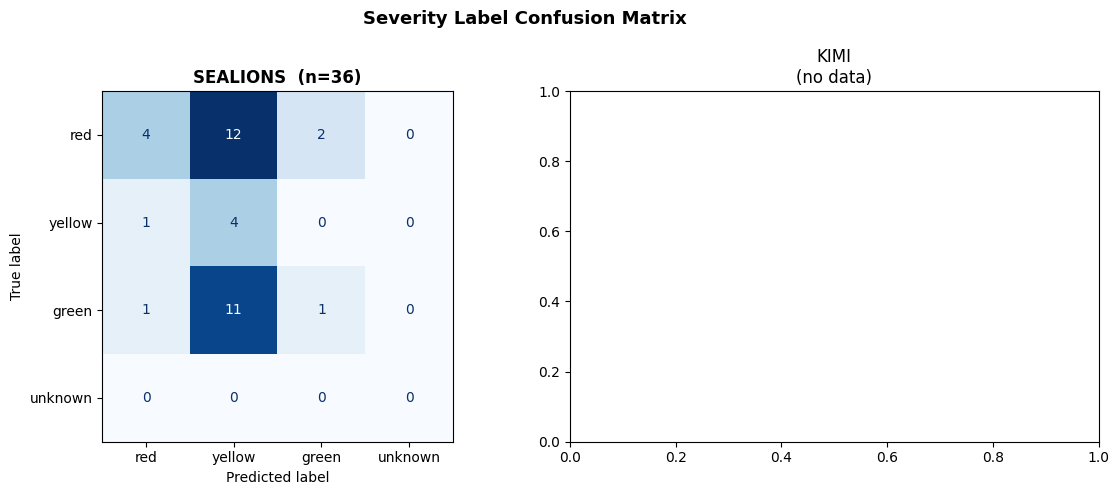


── Common misclassifications ────────────────────────────

SEALIONS — 27 misclassified:
  red      → yellow    ×12
  green    → yellow    ×11
  red      → green     ×2
  green    → red       ×1
  yellow   → red       ×1

KIMI — 0 misclassified:

── Judge disagreement rows (|Gemini-llama| > 0.3) ───────
provider                                                                                             question  gemini_overall  llama_overall                                                                                                                                                                                                                                                                           judge_reasoning
sealions                          มีอาการคันมือคันเท้าหลังอาบน้ำเสร็จ เกิดจากสาเหตุใด มีวิธีแก้หือป้องอย่างไร           0.150           0.55                                                    คำตอบที่ประเมินระบุผิดพลาดว่าข้อมูลอ้างอิงไม่เกี่ยวข้องและกล่าวถึงเรื่องก้อนที่เ

In [60]:
# ── Severity Confusion Matrix ──────────────────────────────
# วิเคราะห์ว่าโมเดลสับสน label ใดกับ label ใดบ้าง
import matplotlib.pyplot as plt
import matplotlib, numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

LABELS = ["red", "yellow", "green", "unknown"]
fig, axes = plt.subplots(1, len(PROVIDERS), figsize=(6*len(PROVIDERS), 5))
if len(PROVIDERS) == 1:
    axes = [axes]

fig.suptitle("Severity Label Confusion Matrix", fontsize=13, fontweight='bold')

for ax, provider in zip(axes, PROVIDERS):
    sub = results_df[
        (results_df["provider"] == provider) &
        (results_df["severity_ref"] != "unknown")   # only evaluate where ref is known
    ].copy()

    if sub.empty:
        ax.set_title(f"{provider.upper()}\n(no data)")
        continue

    y_true = pd.Categorical(sub["severity_ref"],  categories=LABELS)
    y_pred = pd.Categorical(sub["severity_pred"], categories=LABELS)

    cm  = confusion_matrix(y_true, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{provider.upper()}  (n={len(sub)})", fontweight='bold')
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.savefig("out_thai_med_pack/severity_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

# text summary: most common confusions
print("\n── Common misclassifications ────────────────────────────")
for provider in PROVIDERS:
    sub = results_df[
        (results_df["provider"] == provider) &
        (results_df["severity_ref"] != "unknown") &
        (results_df["severity_pred"] != results_df["severity_ref"])
    ]
    print(f"\n{provider.upper()} — {len(sub)} misclassified:")
    if not sub.empty:
        conf = sub.groupby(["severity_ref","severity_pred"]).size().sort_values(ascending=False)
        for (ref, pred), cnt in conf.items():
            print(f"  {ref:8s} → {pred:8s}  ×{cnt}")

# judge disagreement rows
print("\n── Judge disagreement rows (|Gemini-llama| > 0.3) ───────")
dis = results_df[results_df["judge_disagree"] == True][
    ["provider","question","gemini_overall","llama_overall","judge_reasoning"]
]
if dis.empty:
    print("  None — judges agree on all rows ✅")
else:
    print(dis.to_string(index=False))

### Aggregate & Comparison Table

In [61]:
# ── Aggregate per provider ──────────────────────────────────
agg = results_df.groupby("provider").agg(
    n                  = ("question",         "count"),
    semantic_sim       = ("semantic_sim",      "mean"),
    severity_accuracy  = ("severity_correct",  lambda x: x.dropna().mean()),
    dept_accuracy      = ("dept_correct",      lambda x: x.dropna().mean()),
    format_compliance  = ("format_ok",         "mean"),
    judge_correctness  = ("judge_correctness", "mean"),
    judge_safety       = ("judge_safety",      "mean"),
    judge_completeness = ("judge_completeness","mean"),
    judge_fluency      = ("judge_fluency",     "mean"),
    judge_overall      = ("judge_overall",     "mean"),
).round(4).sort_values("judge_overall", ascending=False)

agg.to_csv("out_thai_med_pack/eval_summary.csv", encoding="utf-8-sig")

# Comparison table
rows = []
for provider, row in agg.iterrows():
    rows.append({
        "Model":              provider.upper(),
        "Safety ↑":           f"{row['judge_safety']:.3f}"          if pd.notna(row['judge_safety'])       else "N/A",
        "Severity Acc ↑":     f"{row['severity_accuracy']*100:.1f}%" if pd.notna(row['severity_accuracy']) else "N/A",
        "Semantic Sim ↑":     f"{row['semantic_sim']:.3f}",
        "Format Comply ↑":    f"{row['format_compliance']*100:.1f}%",
        "Fluency ↑":          f"{row['judge_fluency']:.3f}"          if pd.notna(row['judge_fluency'])     else "N/A",
        "LLM Overall ↑":      f"{row['judge_overall']:.3f}"          if pd.notna(row['judge_overall'])     else "N/A",
    })

summary_df = pd.DataFrame(rows).set_index("Model")
print("\n📊 COMPARISON TABLE  (↑ สูงยิ่งดี)")
print("=" * 80)
print(summary_df.to_string())


📊 COMPARISON TABLE  (↑ สูงยิ่งดี)
         Safety ↑ Severity Acc ↑ Semantic Sim ↑ Format Comply ↑ Fluency ↑ LLM Overall ↑
Model                                                                                  
SEALIONS    0.910          25.0%          0.609          100.0%     0.940         0.811


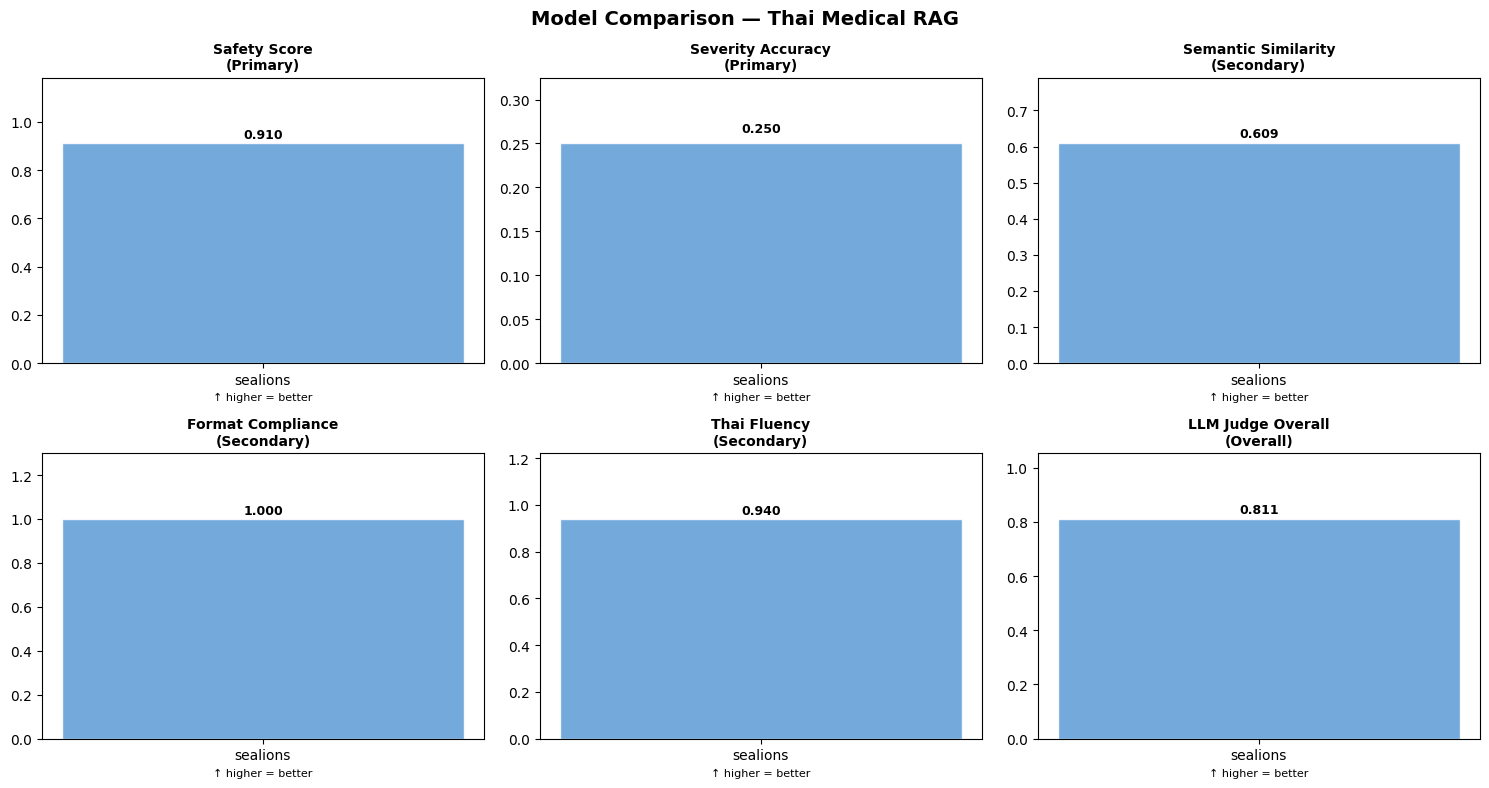

✅ Saved: evaluation_results.png


In [62]:
# ── Bar Charts ──────────────────────────────────────────────
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

providers_ordered = agg.index.tolist()
colors = ['#5B9BD5', '#ED7D31', '#70AD47', '#A9D18E'][:len(providers_ordered)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Model Comparison — Thai Medical RAG", fontsize=14, fontweight='bold')

metrics_plot = [
    ("judge_safety",      "Safety Score",        "Primary"),
    ("severity_accuracy", "Severity Accuracy",   "Primary"),
    ("semantic_sim",      "Semantic Similarity", "Secondary"),
    ("format_compliance", "Format Compliance",   "Secondary"),
    ("judge_fluency",     "Thai Fluency",        "Secondary"),
    ("judge_overall",     "LLM Judge Overall",   "Overall"),
]

for ax, (col, title, cat) in zip(axes.flatten(), metrics_plot):
    vals = [float(agg.loc[p, col]) if pd.notna(agg.loc[p, col]) else 0 for p in providers_ordered]
    bars = ax.bar(providers_ordered, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(f"{title}\n({cat})", fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 1)
    ax.set_xlabel("↑ higher = better", fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: evaluation_results.png")

## Section 9: Analysis & Model Selection

###  Best / Worst Cases per Provider

In [63]:
for provider in providers_ordered:
    sub = (results_df[results_df["provider"] == provider]
           .dropna(subset=["judge_overall"])
           .sort_values("judge_overall", ascending=False))

    print(f"\n{'='*60}")
    print(f"🏆 {provider.upper()} — TOP 2")
    for _, r in sub.head(2).iterrows():
        print(f"  Q  : {r['question'][:80]}")
        print(f"  Gen: {r['answer_generated'][:120]}...")
        print(f"  Safety={r['judge_safety']:.2f} | Overall={r['judge_overall']:.2f}")
        print(f"  → {r['judge_reasoning']}")
        print()

    print(f"⚠️  {provider.upper()} — BOTTOM 2")
    for _, r in sub.tail(2).iterrows():
        print(f"  Q  : {r['question'][:80]}")
        print(f"  Gen: {r['answer_generated'][:120]}...")
        print(f"  Safety={r['judge_safety']:.2f} | Overall={r['judge_overall']:.2f}")
        print(f"  → {r['judge_reasoning']}")
        print()


🏆 SEALIONS — TOP 2
  Q  : หนูขับรถอยู่ไม่เร็วมาก รถล้มเเล้วคางไปกระแทกกับพื้น อาการตอนนี้คือปวดกรามและปวดฟ
  Gen: 1. **การประเมินอาการ:** ผู้ป่วยประสบอุบัติเหตุรถล้ม คางกระแทกพื้น มีอาการปวดกราม ปวดฟันล่างด้านหน้า อ้าปากลำบาก พูดลำบาก...
  Safety=0.95 | Overall=0.90
  → คำตอบประเมินความเสี่ยงได้ถูกต้องและแนะนำแผนกที่เกี่ยวข้องกับอาการบาดเจ็บที่กรามและฟันได้อย่างครบถ้วน การระบุระดับความรุนแรงและการส่งต่อผู้ป่วยมีความปลอดภัยและเหมาะสมกับสถานการณ์

  Q  : ฉันป่วยและขาดน้ำ ลดน้ำหนัก 6.5 ปอนด์ใน 2 วันครึ่ง อังคาร พุธ และพฤหัสบดี ก่อนที่
  Gen: 1. **การประเมินอาการ:** ผู้ป่วยมีอาการป่วย, ขาดน้ำ, น้ำหนักลดลงอย่างรวดเร็ว (6.5 ปอนด์ใน 2.5 วัน), และผลเลือดแสดงค่า SGP...
  Safety=0.95 | Overall=0.90
  → คำตอบที่สร้างขึ้นมีการประเมินความรุนแรงระดับสีเหลืองที่เหมาะสมกับอาการขาดน้ำและน้ำหนักลดอย่างรวดเร็วในผู้ป่วยเบาหวาน ข้อมูลมีความครบถ้วนและใช้ภาษาไทยที่ถูกต้องเป็นมืออาชีพมากกว่าคำตอบอ้างอิงที่มีข้อผิดพลาดในการแปล

⚠️  SEALIONS — BOTTOM 2
  Q  : สามารถรับประทานยาฆ่าเชื้อได้หรือไม่ รักษาอาการไซนัส

### Trade-off Analysis

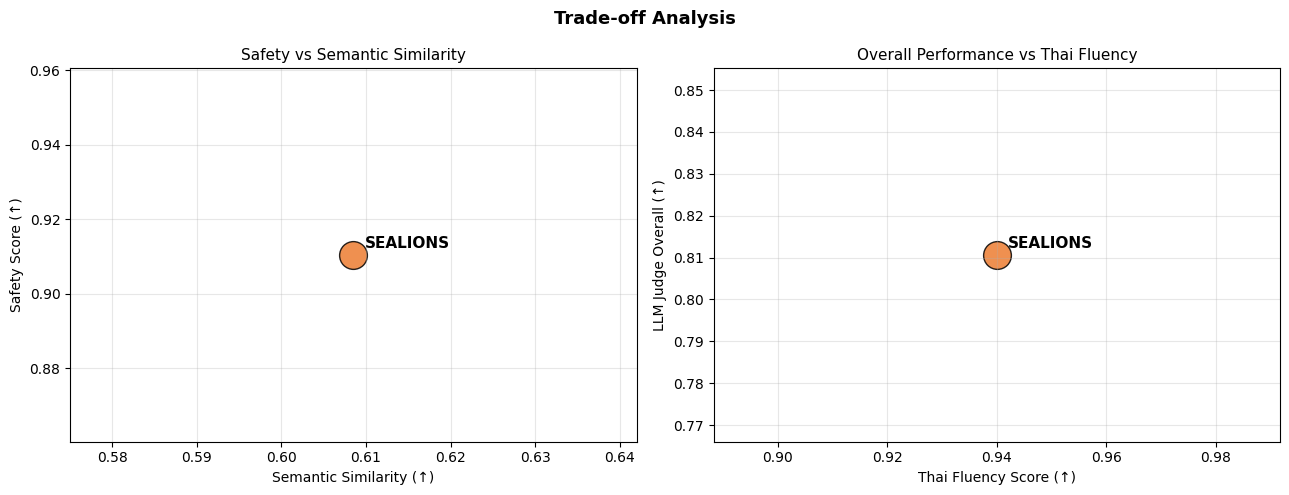

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Trade-off Analysis", fontsize=13, fontweight='bold')
color_map = {"gemini": "#5B9BD5", "sealions": "#ED7D31", "kimi": "#70AD47"}

# Plot 1: Safety vs Semantic Similarity
ax1 = axes[0]
for p in providers_ordered:
    r = agg.loc[p]
    ax1.scatter(float(r["semantic_sim"]),
                float(r["judge_safety"]) if pd.notna(r["judge_safety"]) else 0,
                s=400, c=color_map.get(p, "gray"), alpha=0.85, edgecolors='black')
    ax1.annotate(p.upper(), (float(r["semantic_sim"]),
                 float(r["judge_safety"]) if pd.notna(r["judge_safety"]) else 0),
                 textcoords="offset points", xytext=(8,5), fontsize=11, fontweight='bold')
ax1.set_xlabel("Semantic Similarity (↑)", fontsize=10)
ax1.set_ylabel("Safety Score (↑)", fontsize=10)
ax1.set_title("Safety vs Semantic Similarity", fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Overall vs Fluency
ax2 = axes[1]
for p in providers_ordered:
    r = agg.loc[p]
    ov = float(r["judge_overall"]) if pd.notna(r["judge_overall"]) else 0
    fl = float(r["judge_fluency"]) if pd.notna(r["judge_fluency"]) else 0
    ax2.scatter(fl, ov, s=400, c=color_map.get(p, "gray"),
                alpha=0.85, edgecolors='black')
    ax2.annotate(p.upper(), (fl, ov), textcoords="offset points",
                 xytext=(8,5), fontsize=11, fontweight='bold')
ax2.set_xlabel("Thai Fluency Score (↑)", fontsize=10)
ax2.set_ylabel("LLM Judge Overall (↑)", fontsize=10)
ax2.set_title("Overall Performance vs Thai Fluency", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tradeoff_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

Model selection

In [65]:
# ── Model Selection Decision ────────────────────────────────
best_safety  = agg["judge_safety"].idxmax()
best_overall = agg["judge_overall"].idxmax()
selected     = best_safety   # primary criterion = safety

print("=" * 60)
print("MODEL SELECTION")
print("=" * 60)
print(f"Best Safety Score  : {best_safety.upper()}")
print(f"Best Overall Score : {best_overall.upper()}")
print(f"\n✅ SELECTED: {selected.upper()}  (primary criterion = safety)")
print("   เหตุผล: under-triage ผู้ป่วยฉุกเฉิน = อันตรายถึงชีวิต")
print("          Safety Score ต้องเป็น criterion หลักในระบบทางการแพทย์")
print()

# Final report card
print(f"{'Provider':<12} {'Safety':>8} {'Sev.Acc':>9} {'Semantic':>9} {'Format':>8} {'Fluency':>8} {'Overall':>8}")
print("-" * 68)
for p, row in agg.iterrows():
    tag = " ← SELECTED" if p == selected else ""
    sev = f"{row['severity_accuracy']*100:.1f}%" if pd.notna(row['severity_accuracy']) else "N/A"
    print(f"{p.upper():<12} {row['judge_safety']:>8.3f} {sev:>9} {row['semantic_sim']:>9.3f} "
          f"{row['format_compliance']:>8.3f} {row['judge_fluency']:>8.3f} {row['judge_overall']:>8.3f}{tag}")

print("\n" + "=" * 60)
print(f"Evaluated on {len(predict_df)} test cases | Judge: Gemini (independent)")
print("Primary criterion: Safety Score (under-triage = highest risk)")

MODEL SELECTION
Best Safety Score  : SEALIONS
Best Overall Score : SEALIONS

✅ SELECTED: SEALIONS  (primary criterion = safety)
   เหตุผล: under-triage ผู้ป่วยฉุกเฉิน = อันตรายถึงชีวิต
          Safety Score ต้องเป็น criterion หลักในระบบทางการแพทย์

Provider       Safety   Sev.Acc  Semantic   Format  Fluency  Overall
--------------------------------------------------------------------
SEALIONS        0.910     25.0%     0.609    1.000    0.940    0.811 ← SELECTED

Evaluated on 100 test cases | Judge: Gemini (independent)
Primary criterion: Safety Score (under-triage = highest risk)


In [66]:
# ── Final Export ────────────────────────────────────────────
import os
os.makedirs("out_thai_med_pack", exist_ok=True)

results_df.to_csv("out_thai_med_pack/eval_results.csv",   index=False, encoding="utf-8-sig")
agg.to_csv(       "out_thai_med_pack/eval_summary.csv",               encoding="utf-8-sig")
predict_df.to_csv("out_thai_med_pack/predictions.csv",    index=False, encoding="utf-8-sig")

print("✅ All files saved:")
print("   predictions.csv     — raw answers per provider")
print("   eval_results.csv    — per-case scores")
print("   eval_summary.csv    — aggregate per model")
print("   evaluation_results.png")
print("   tradeoff_analysis.png")
print()

display(agg[[
    "judge_safety", "severity_accuracy", "semantic_sim",
    "format_compliance", "judge_fluency", "judge_overall"
]].style
  .highlight_max(axis=0, color='lightgreen')
  .format("{:.3f}"))

✅ All files saved:
   predictions.csv     — raw answers per provider
   eval_results.csv    — per-case scores
   eval_summary.csv    — aggregate per model
   evaluation_results.png
   tradeoff_analysis.png



,judge_safety,severity_accuracy,semantic_sim,format_compliance,judge_fluency,judge_overall
provider,,,,,,
sealions,0.910,0.250,0.609,1.000,0.940,0.811
